# EDA — Dataset Scoring Épargne (`final.csv`)

Notebook d'exploration visuelle du dataset final (post feature engineering) : 4005 lignes, 45 colonnes.

**Objectif** : comprendre chaque colonne, sa distribution, et les relations entre colonnes (y compris avec la variable cible `label_nom` / `label_code`).

**Plan** :
1. Chargement & aperçu général
2. Qualité des données (valeurs manquantes, doublons, cardinalité)
3. Variable cible
4. Distribution des variables numériques
5. Distribution des variables catégorielles
6. Colonnes indicatrices / flags binaires
7. Corrélations entre variables numériques
8. Relations variables numériques ↔ cible
9. Relations variables catégorielles ↔ cible
10. Synthèse


## 1. Setup & chargement des données

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", 100)

DATA_PATH = "final.csv"  # adapter le chemin si besoin
df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head()


(4008, 40)


,RADICAL,BANQUE,AGENCE,GENERIC,PLURAL,CCLE,DATE_OF_BIRTH,CODE_VILLE,LIBELLE_VILLE,BPR,GENDER,MARITAL_STATUS,NOMBRE_ENFANT,CUSTOMER_RATING,TAILLE_ENTREPRI,age_client,label_code,label_nom,pack_actuel,pack_etat,digital_date_activation,digital_toujours_abonne,solde_moyen,solde_min,solde_max,nb_mois_observes_solde,depot_moyen,flux_cred_moyen,flux_cred_total,nb_mois_avec_flux,nb_operations_gab,montant_total_gab,montant_moyen_gab,derniere_operation_gab,nb_retraits,montant_total_retraits,nb_paiements_digitaux,montant_total_payfac,nb_vignettes_payees,montant_total_vignette
0,1316,45,57,21111,0,7,17/10/1997,101,FKIH BEN SALAH,45.0,Masculin,9,0.0,SVC,NaN,28,9,MaRetraite,PLOC1,W,07/11/2017,1,-709.570000,-1204.57,-456.57,24,NaN,0.000000,0.00,0,0,0.0,NaN,NaN,0,0.0,0,0.0,0,0.0
1,1490,77,83,21111,0,5,26/06/1994,780,CASABLANCA,78.0,Masculin,1,0.0,SVC,NaN,31,9,MaRetraite,PLOC1,W,NaN,0,-2285.043220,-7245.24,0.00,59,NaN,0.000000,0.00,0,0,0.0,NaN,NaN,0,0.0,0,0.0,0,0.0
2,8376,79,84,21111,0,9,14/10/1993,780,CASABLANCA,78.0,Masculin,1,0.0,SVC,NaN,32,9,MaRetraite,PLOCI,W,05/03/2015,1,-2155.240000,-2772.99,-1506.68,24,NaN,0.000000,0.00,0,0,0.0,NaN,NaN,0,0.0,0,0.0,0,0.0
3,9481,78,48,21111,0,9,01/01/1972,780,CASABLANCA,78.0,Masculin,1,0.0,SVC,NaN,53,9,MaRetraite,PLOCI,W,NaN,0,-688.235417,-1085.50,-291.01,24,NaN,0.000000,0.00,0,0,0.0,NaN,NaN,0,0.0,0,0.0,0,0.0
4,10972,78,84,21111,0,3,26/12/1990,780,CASABLANCA,78.0,Masculin,1,0.0,SVC,NaN,35,9,MaRetraite,PLOCI,W,NaN,0,209.811875,-10.43,1452.78,48,314.165238,324.755769,8443.65,8,2,0.0,0.0,2024-09-27 10:34:22,1,100.0,0,0.0,0,0.0


In [49]:
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
RADICAL,4008.0,NaN,NaN,NaN,4983363.746257,2946557.701563,1316.0,2473976.0,4664796.5,7618169.25,9999872.0
BANQUE,4008.0,NaN,NaN,NaN,53.855788,24.700849,1.0,45.0,54.0,78.0,83.0
AGENCE,4008.0,NaN,NaN,NaN,45.882485,27.443422,1.0,22.0,44.0,68.0,99.0
GENERIC,4008.0,NaN,NaN,NaN,21113.223303,11.685005,21111.0,21111.0,21111.0,21111.0,21216.0
PLURAL,4008.0,NaN,NaN,NaN,0.666168,3.713045,0.0,0.0,0.0,0.0,95.0
CCLE,4008.0,NaN,NaN,NaN,4.410928,2.893682,0.0,2.0,4.0,7.0,9.0
DATE_OF_BIRTH,4008,2941,01/01/1972,32,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CODE_VILLE,4008,273,780,713,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LIBELLE_VILLE,3856,236,CASABLANCA,713,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BPR,4006.0,NaN,NaN,NaN,52.087868,25.429018,1.0,27.0,50.0,78.0,81.0


## 2. Qualité des données

Valeurs manquantes, doublons, cardinalité de chaque colonne.

In [50]:
n_dupes = df.duplicated().sum()
print(f"Nombre de lignes dupliquées : {n_dupes}")


Nombre de lignes dupliquées : 0


In [51]:
cardinality = df.nunique().sort_values(ascending=False)
cardinality.to_frame("n_valeurs_uniques")


,n_valeurs_uniques
RADICAL,4008
solde_moyen,3981
solde_max,3897
solde_min,3580
depot_moyen,3390
flux_cred_moyen,3144
flux_cred_total,3116
DATE_OF_BIRTH,2941
derniere_operation_gab,2124
digital_date_activation,1976


## 3. Variable cible

`label_nom` (et son encodage `label_code`) représente le produit d'épargne — c'est la cible de prédiction.

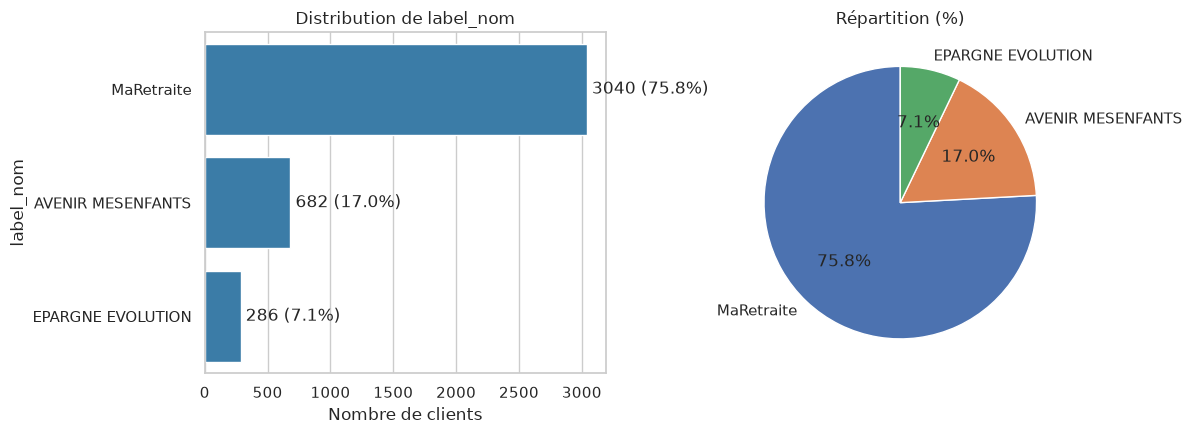

Déséquilibre des classes — à garder en tête pour la modélisation.


In [52]:
target_counts = df["label_nom"].value_counts()
target_pct = (target_counts / len(df) * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.barplot(x=target_counts.values, y=target_counts.index, ax=axes[0], color="#2980b9")
axes[0].set_xlabel("Nombre de clients")
axes[0].set_title("Distribution de label_nom")
for i, v in enumerate(target_counts.values):
    axes[0].text(v, i, f" {v} ({target_pct.iloc[i]}%)", va="center")

axes[1].pie(target_counts.values, labels=target_counts.index, autopct="%1.1f%%", startangle=90,
            colors=sns.color_palette("deep"))
axes[1].set_title("Répartition (%)")
plt.tight_layout()
plt.show()

print("Déséquilibre des classes — à garder en tête pour la modélisation.")


## 4. Distribution des variables numériques

On sépare les variables numériques "continues/comptages" des colonnes indicatrices binaires (`*_etait_extreme`, `jamais_*`), traitées séparément en section 6.

In [53]:
all_num_cols = df.select_dtypes(include="number").columns.tolist()

flag_cols = [c for c in all_num_cols if c.endswith("_etait_extreme") or c.startswith("jamais_")]
target_like = ["label_code"]
real_num_cols = [c for c in all_num_cols if c not in flag_cols and c not in target_like]

print(f"Variables numériques 'continues' : {len(real_num_cols)}")
print(real_num_cols)
print()
print(f"Colonnes indicatrices binaires : {len(flag_cols)}")
print(flag_cols)


Variables numériques 'continues' : 29
['RADICAL', 'BANQUE', 'AGENCE', 'GENERIC', 'PLURAL', 'CCLE', 'BPR', 'MARITAL_STATUS', 'NOMBRE_ENFANT', 'TAILLE_ENTREPRI', 'age_client', 'digital_toujours_abonne', 'solde_moyen', 'solde_min', 'solde_max', 'nb_mois_observes_solde', 'depot_moyen', 'flux_cred_moyen', 'flux_cred_total', 'nb_mois_avec_flux', 'nb_operations_gab', 'montant_total_gab', 'montant_moyen_gab', 'nb_retraits', 'montant_total_retraits', 'nb_paiements_digitaux', 'montant_total_payfac', 'nb_vignettes_payees', 'montant_total_vignette']

Colonnes indicatrices binaires : 0
[]


In [54]:
df[real_num_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
RADICAL,4008.0,4.983364e+06,2.946558e+06,1316.000000,2.473976e+06,4.664796e+06,7.618169e+06,9.999872e+06
BANQUE,4008.0,5.385579e+01,2.470085e+01,1.000000,4.500000e+01,5.400000e+01,7.800000e+01,8.300000e+01
AGENCE,4008.0,4.588249e+01,2.744342e+01,1.000000,2.200000e+01,4.400000e+01,6.800000e+01,9.900000e+01
GENERIC,4008.0,2.111322e+04,1.168501e+01,21111.000000,2.111100e+04,2.111100e+04,2.111100e+04,2.121600e+04
PLURAL,4008.0,6.661677e-01,3.713045e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,9.500000e+01
CCLE,4008.0,4.410928e+00,2.893682e+00,0.000000,2.000000e+00,4.000000e+00,7.000000e+00,9.000000e+00
BPR,4006.0,5.208787e+01,2.542902e+01,1.000000,2.700000e+01,5.000000e+01,7.800000e+01,8.100000e+01
MARITAL_STATUS,4008.0,2.844311e+00,2.355632e+00,1.000000,1.000000e+00,3.000000e+00,3.000000e+00,9.000000e+00
NOMBRE_ENFANT,3742.0,7.966328e-01,1.241516e+00,0.000000,0.000000e+00,0.000000e+00,2.000000e+00,1.600000e+01
TAILLE_ENTREPRI,2.0,9.900000e+01,0.000000e+00,99.000000,9.900000e+01,9.900000e+01,9.900000e+01,9.900000e+01


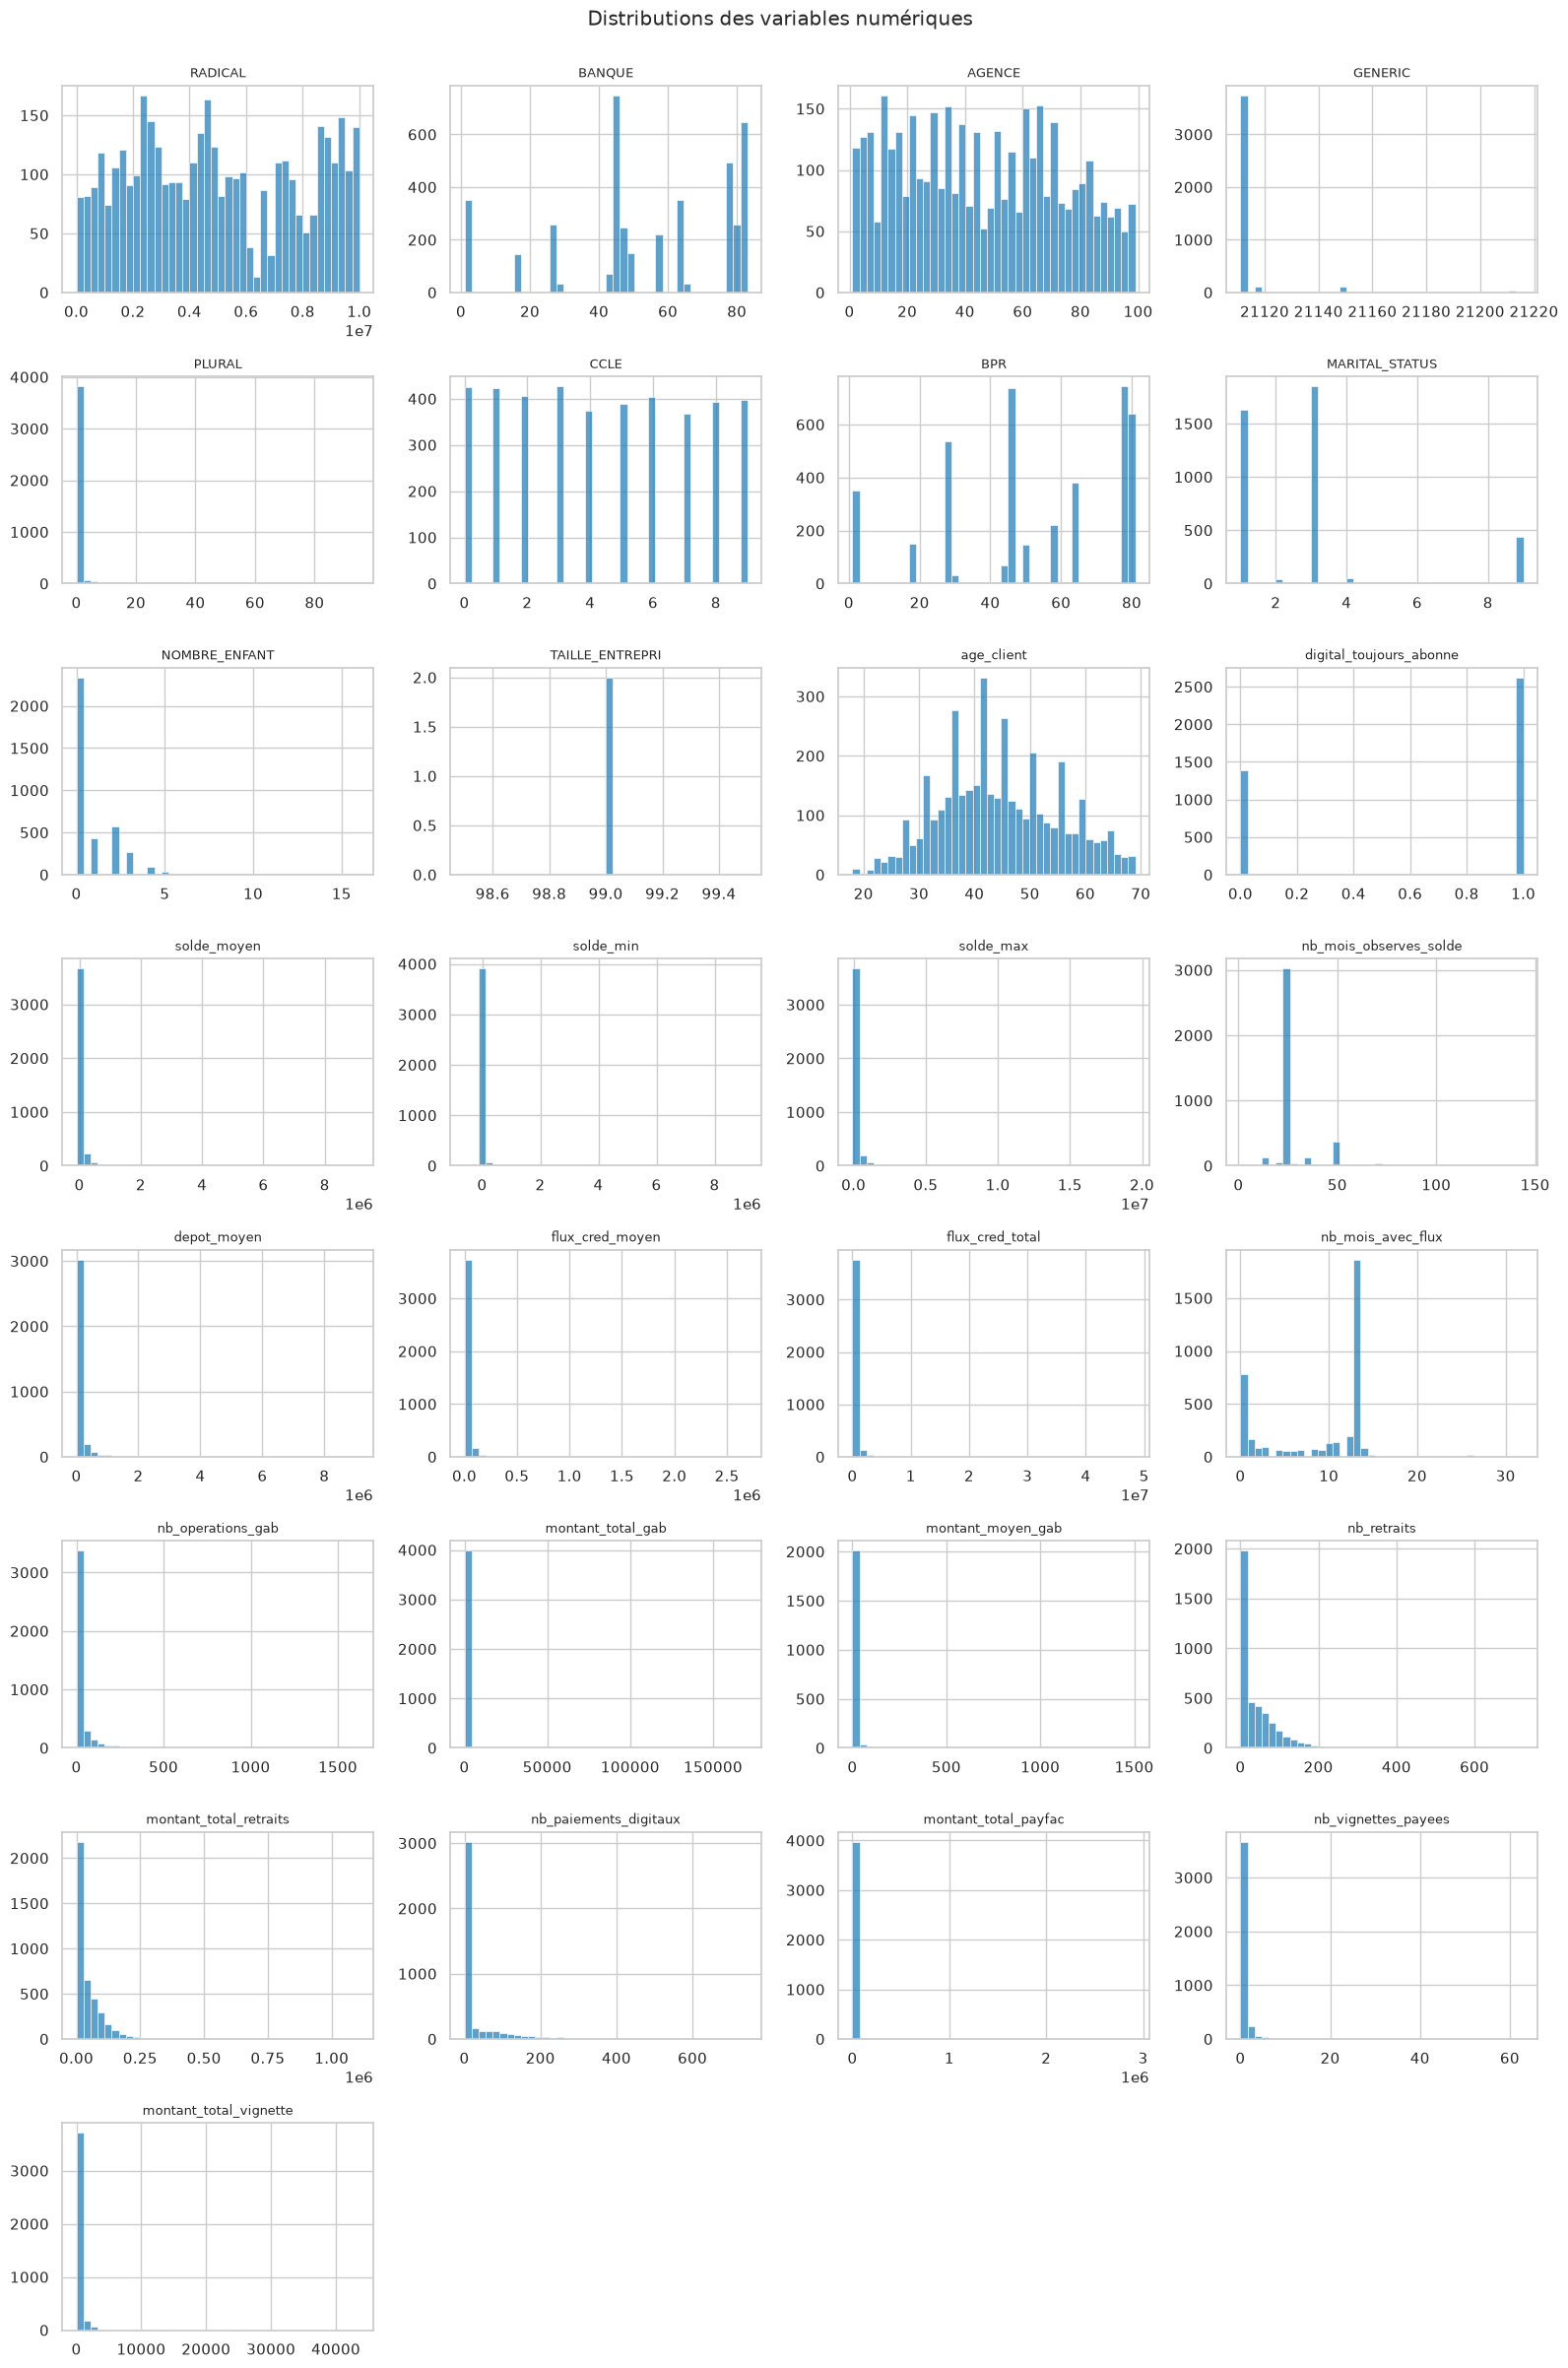

In [55]:
# Histogrammes de toutes les variables numériques "continues"
n = len(real_num_cols)
ncols = 4
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*4, nrows*3))
axes = axes.flatten()

for i, col in enumerate(real_num_cols):
    ax = axes[i]
    sns.histplot(df[col].dropna(), bins=40, ax=ax, color="#2980b9", kde=False)
    ax.set_title(col, fontsize=9)
    ax.set_xlabel("")
    ax.set_ylabel("")

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Distributions des variables numériques", y=1.001)
plt.tight_layout()
plt.show()


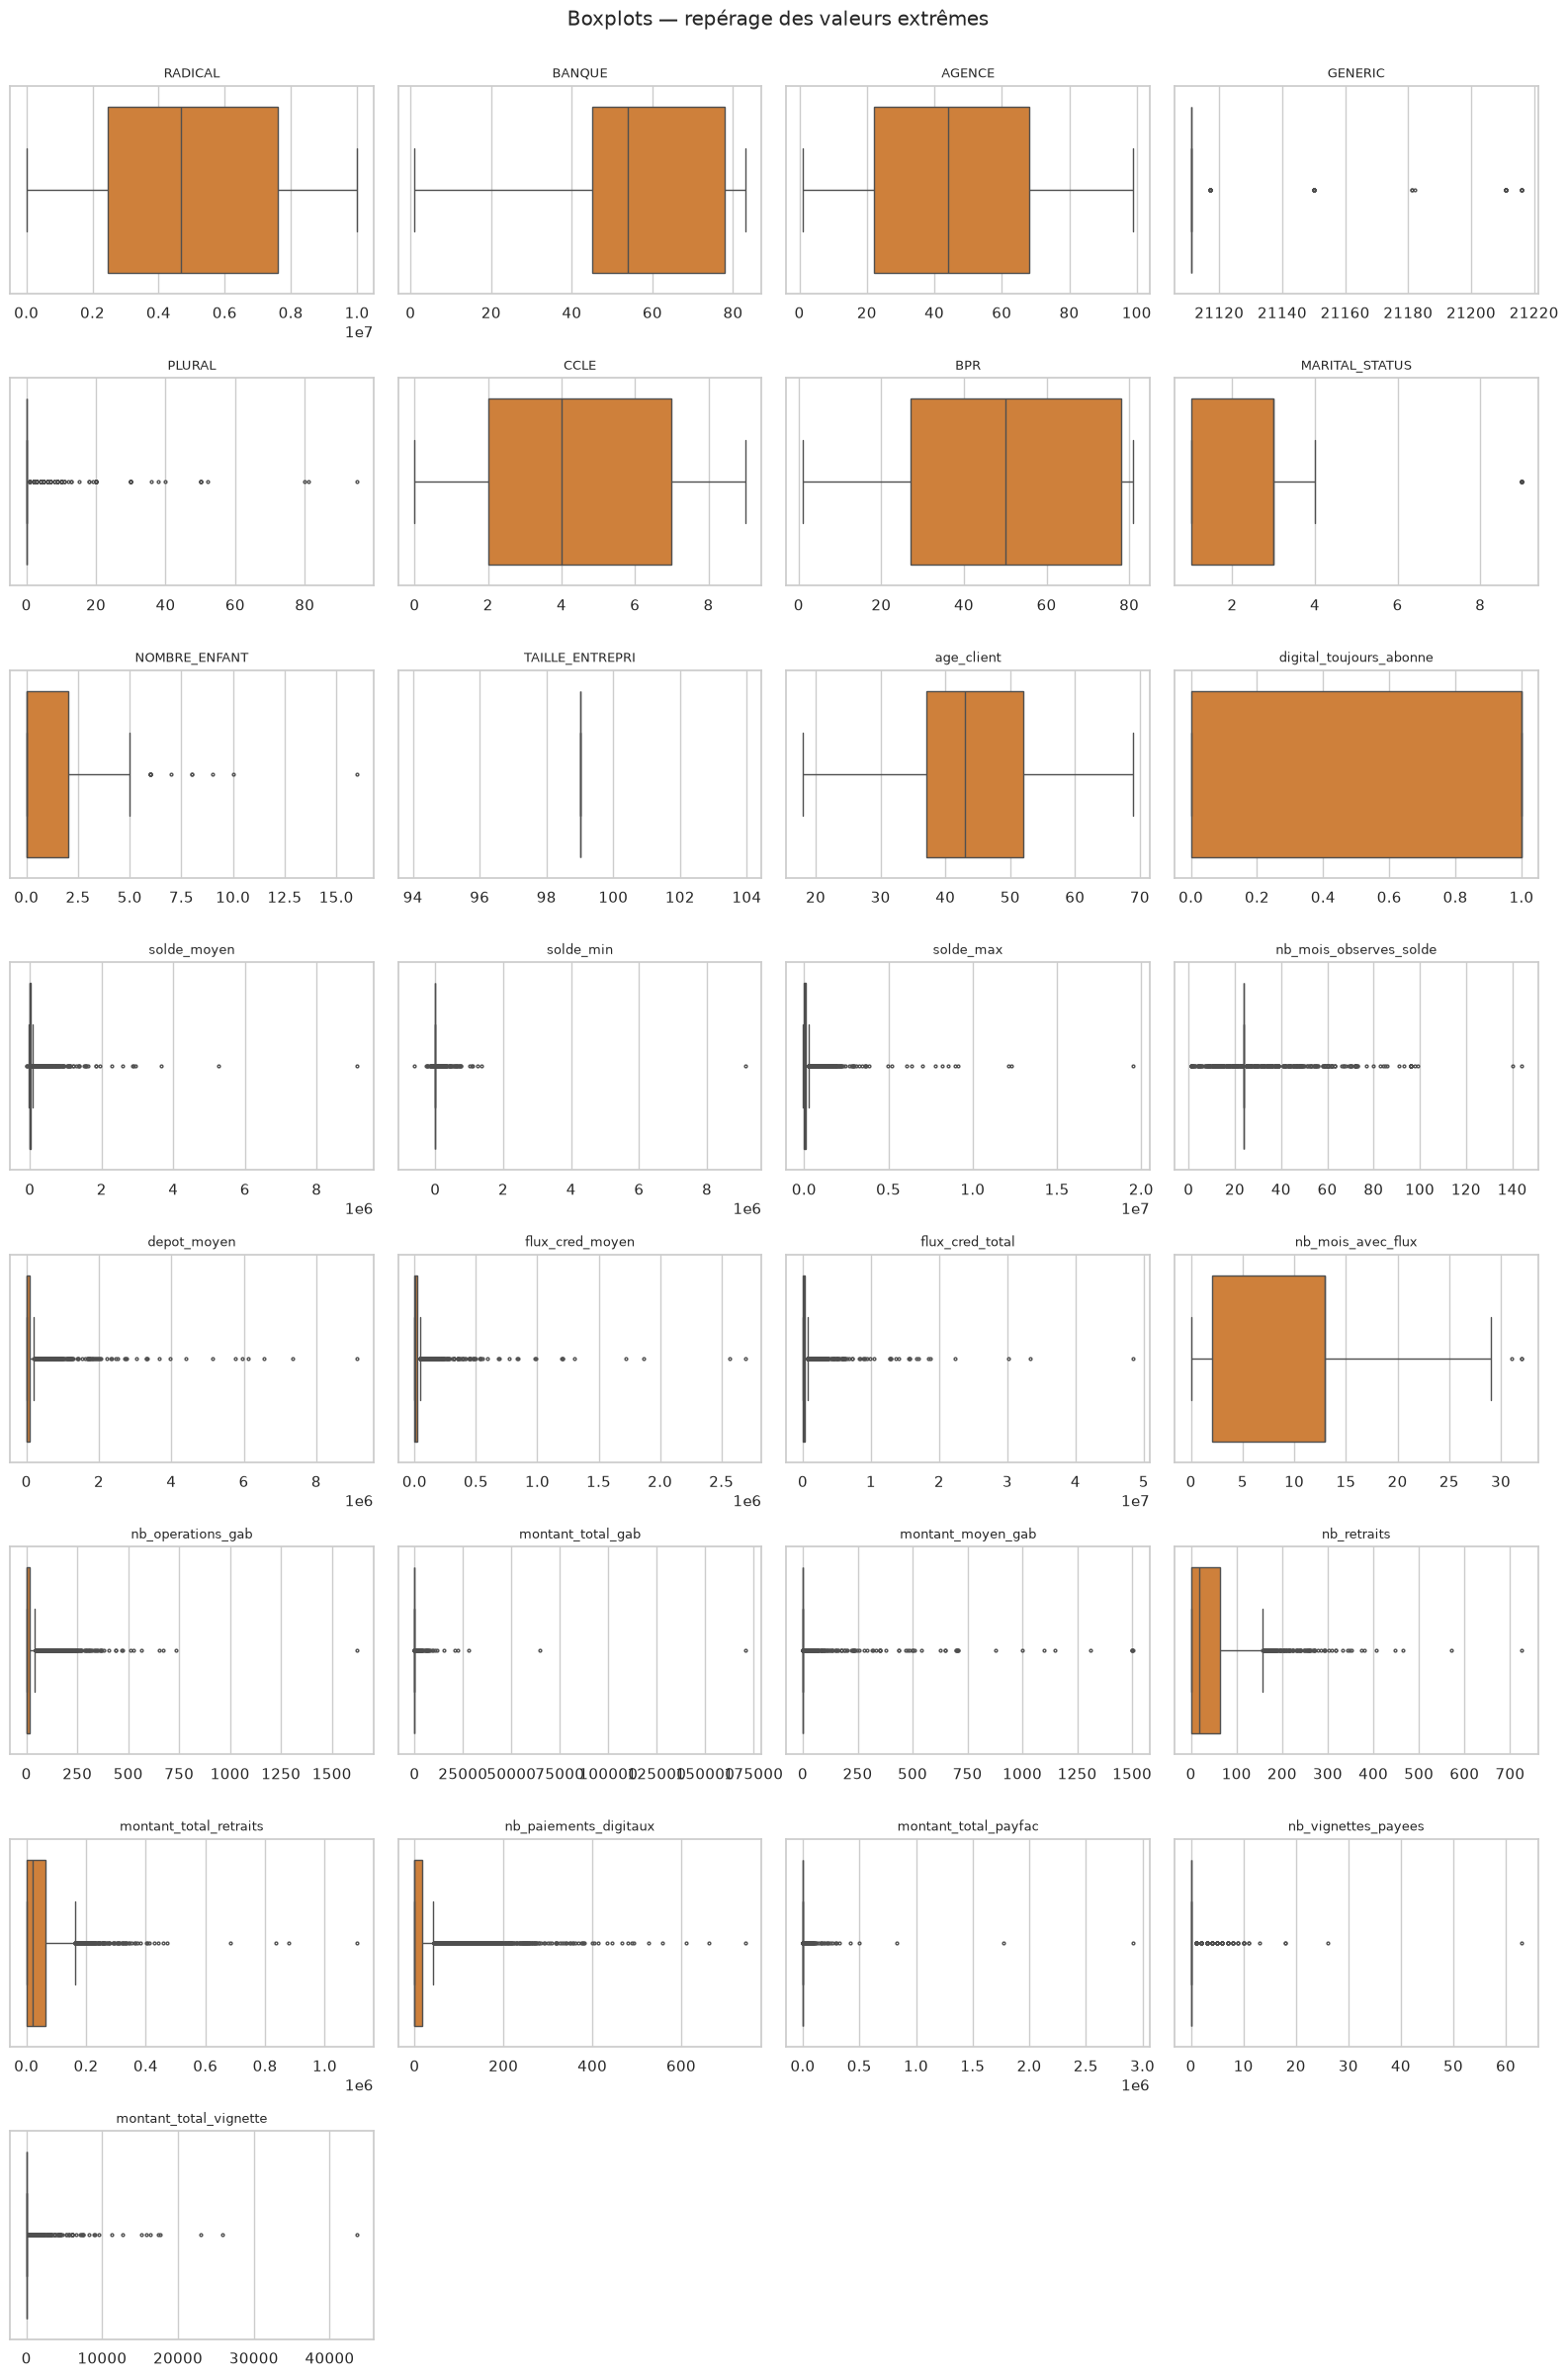

In [56]:
# Boxplots pour repérer visuellement les outliers
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*4, nrows*3))
axes = axes.flatten()

for i, col in enumerate(real_num_cols):
    ax = axes[i]
    sns.boxplot(x=df[col].dropna(), ax=ax, color="#e67e22", fliersize=2)
    ax.set_title(col, fontsize=9)
    ax.set_xlabel("")

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Boxplots — repérage des valeurs extrêmes", y=1.001)
plt.tight_layout()
plt.show()


In [57]:
# Skewness / asymétrie de chaque variable numérique continue
skew_df = df[real_num_cols].skew().sort_values(ascending=False).to_frame("skewness")
skew_df["interpretation"] = pd.cut(
    skew_df["skewness"].abs(),
    bins=[-0.01, 0.5, 1, np.inf],
    labels=["≈ symétrique", "modérément asymétrique", "fortement asymétrique"]
)
skew_df


,skewness,interpretation
solde_min,48.077233,fortement asymétrique
montant_total_gab,48.039056,fortement asymétrique
montant_total_payfac,38.144794,fortement asymétrique
nb_vignettes_payees,18.933635,fortement asymétrique
solde_moyen,18.923167,fortement asymétrique
montant_total_vignette,15.521563,fortement asymétrique
solde_max,15.216851,fortement asymétrique
flux_cred_moyen,15.198943,fortement asymétrique
flux_cred_total,14.898728,fortement asymétrique
PLURAL,14.233013,fortement asymétrique


## 5. Distribution des variables catégorielles

Pour les colonnes à forte cardinalité (`CODE_VILLE`, `pack_actuel`), seules les modalités les plus fréquentes sont affichées.

In [58]:
cat_cols = df.select_dtypes(include="object").columns.tolist()
cat_cols = [c for c in cat_cols if c != "label_nom"]  # déjà traité en section 3
print(cat_cols)


['DATE_OF_BIRTH', 'CODE_VILLE', 'LIBELLE_VILLE', 'GENDER', 'CUSTOMER_RATING', 'pack_actuel', 'pack_etat', 'digital_date_activation', 'derniere_operation_gab']


/tmp/ipykernel_383493/3033886653.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include="object").columns.tolist()


In [59]:
for col in cat_cols:
    n_unique = df[col].nunique()
    print(f"{col} : {n_unique} modalités")


DATE_OF_BIRTH : 2941 modalités
CODE_VILLE : 273 modalités
LIBELLE_VILLE : 236 modalités
GENDER : 2 modalités
CUSTOMER_RATING : 10 modalités
pack_actuel : 49 modalités
pack_etat : 2 modalités
digital_date_activation : 1976 modalités
derniere_operation_gab : 2124 modalités


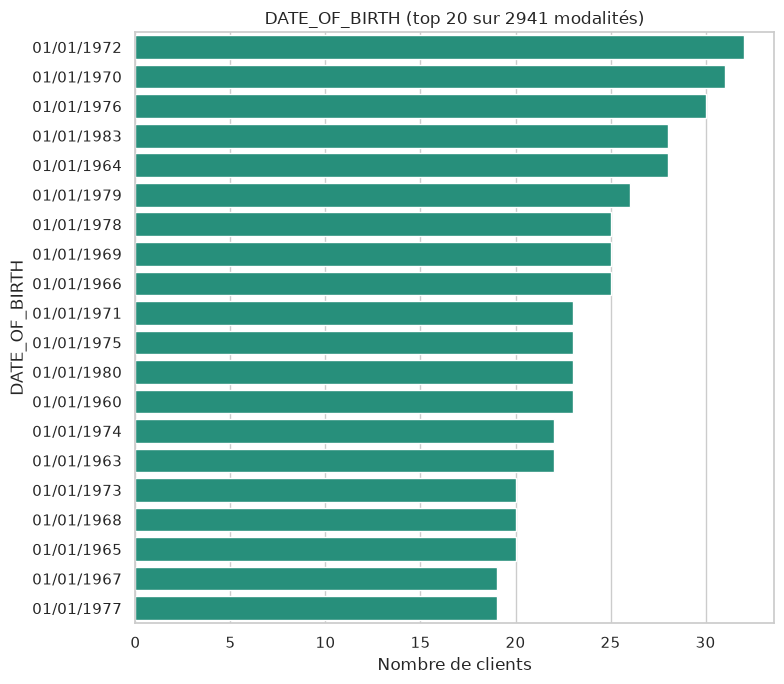

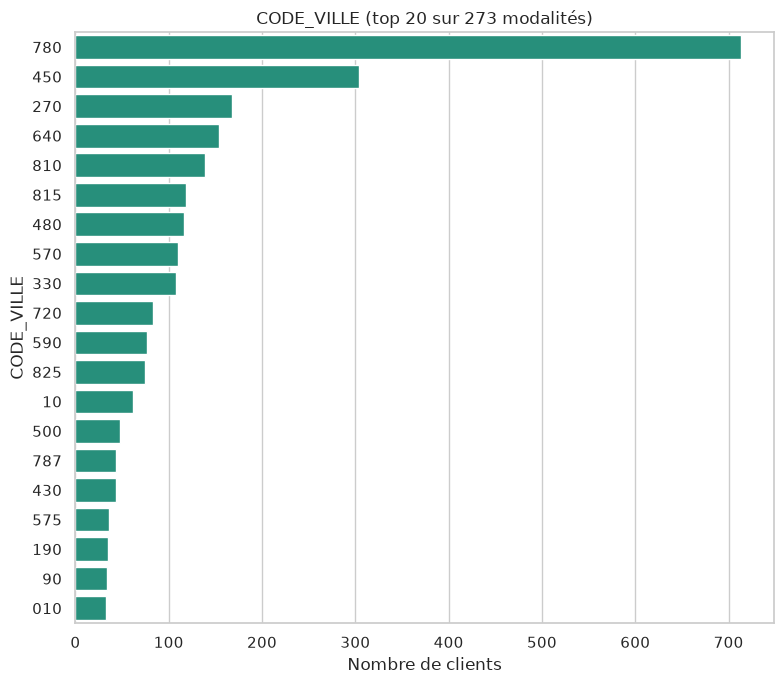

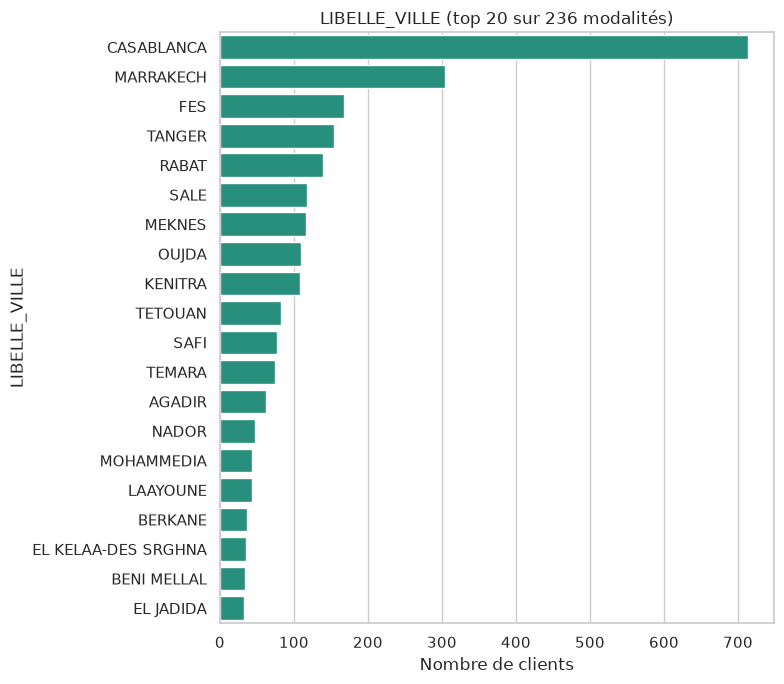

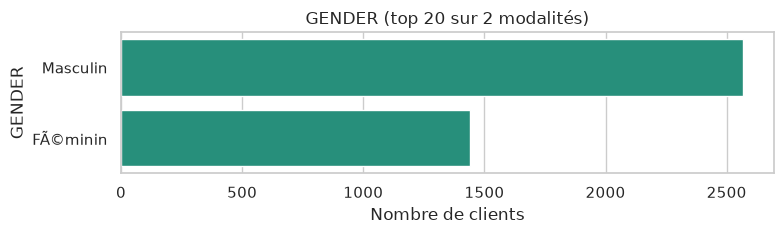

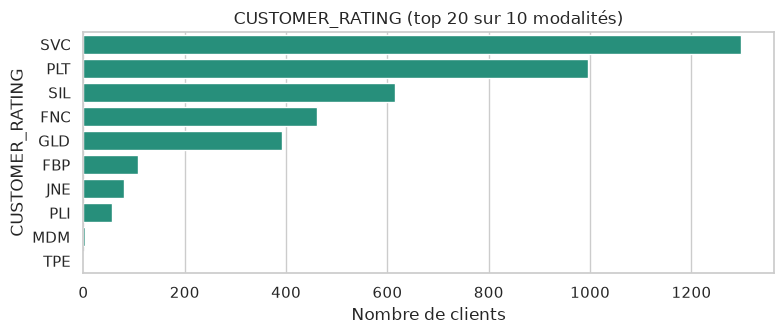

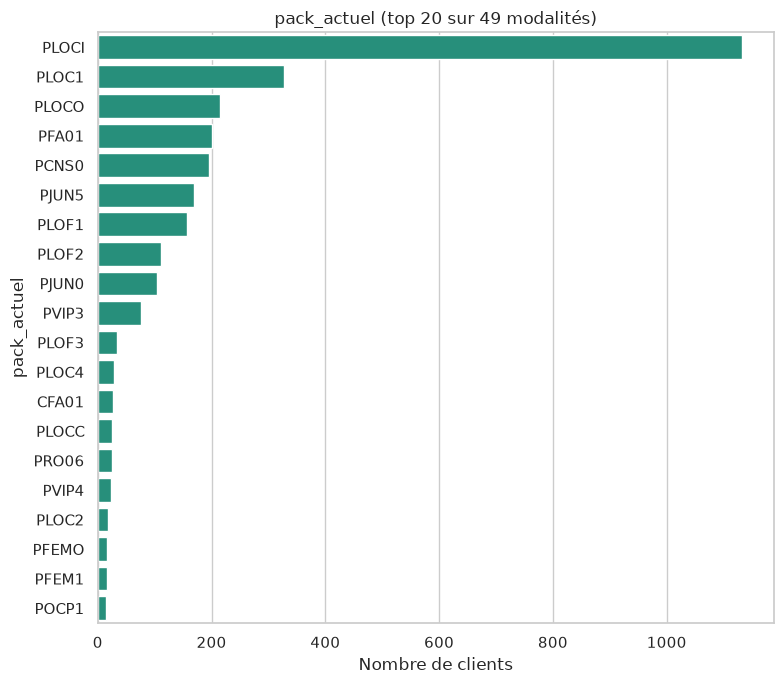

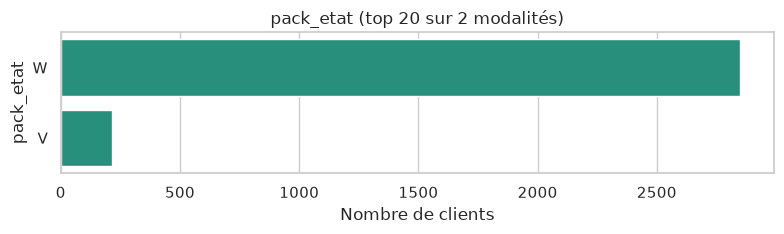

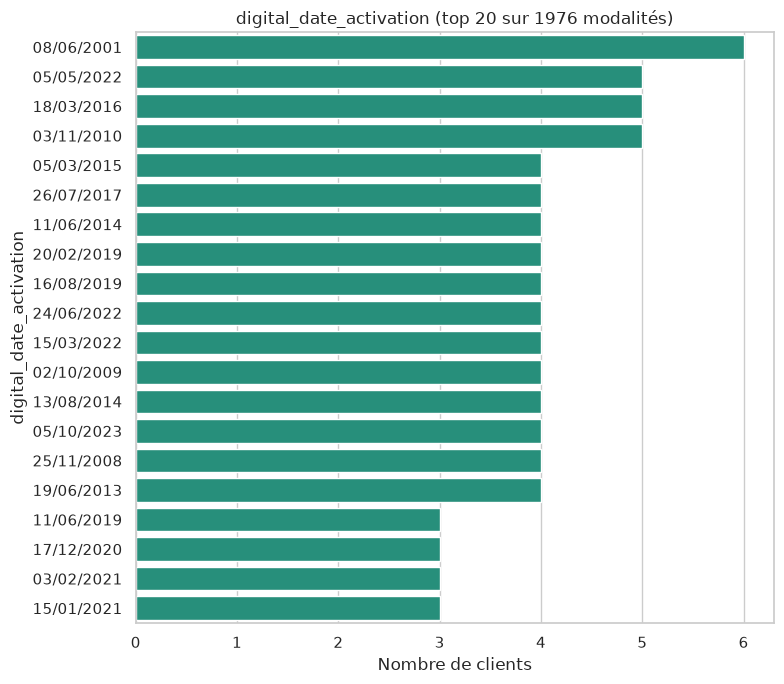

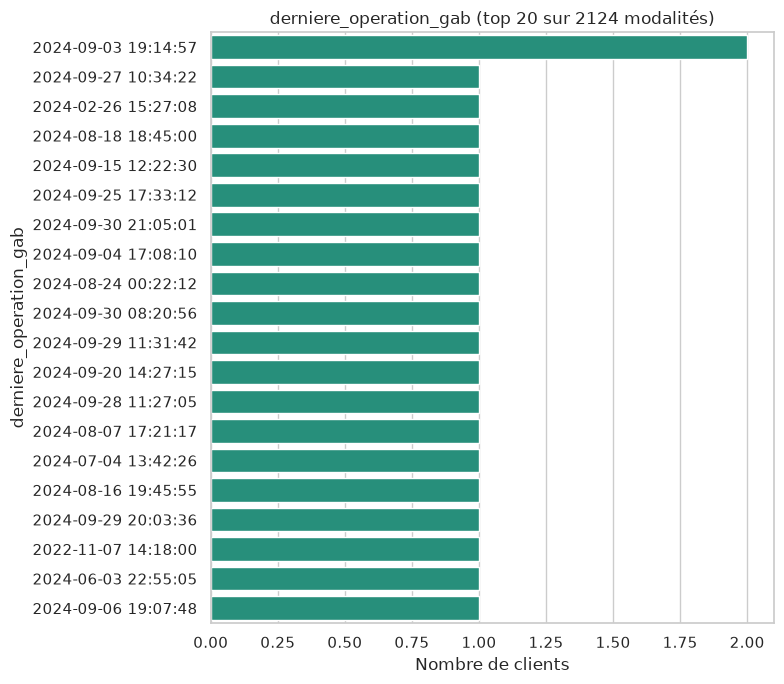

In [60]:
for col in cat_cols:
    counts = df[col].value_counts()
    top = counts.head(20)
    fig, ax = plt.subplots(figsize=(8, max(2.5, 0.35*len(top))))
    sns.barplot(x=top.values, y=top.index.astype(str), ax=ax, color="#16a085")
    title = col if n_unique <= 20 else f"{col} (top 20 sur {df[col].nunique()} modalités)"
    ax.set_title(title)
    ax.set_xlabel("Nombre de clients")
    plt.tight_layout()
    plt.show()


## 6. Colonnes indicatrices / flags binaires

Proportion de clients à 1 pour chaque flag (`*_etait_extreme`, `jamais_active_digital`, `jamais_utilise_gab`, ...).

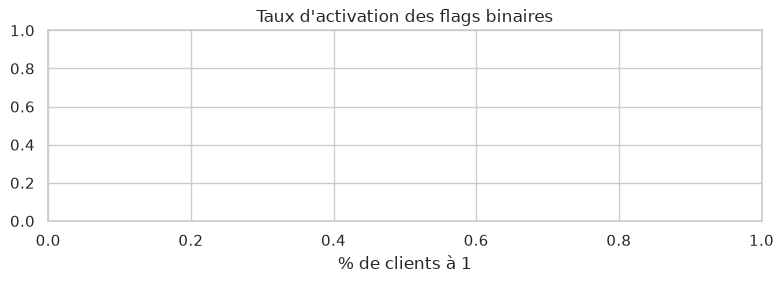

,pct_a_1


In [61]:
flag_rates = (df[flag_cols].mean() * 100).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, max(3, 0.35*len(flag_cols))))
sns.barplot(x=flag_rates.values, y=flag_rates.index, ax=ax, color="#8e44ad")
ax.set_xlabel("% de clients à 1")
ax.set_title("Taux d'activation des flags binaires")
plt.tight_layout()
plt.show()

flag_rates.to_frame("pct_a_1")


## 7. Corrélations entre variables numériques

Matrice de corrélation (Pearson) sur les variables numériques continues.

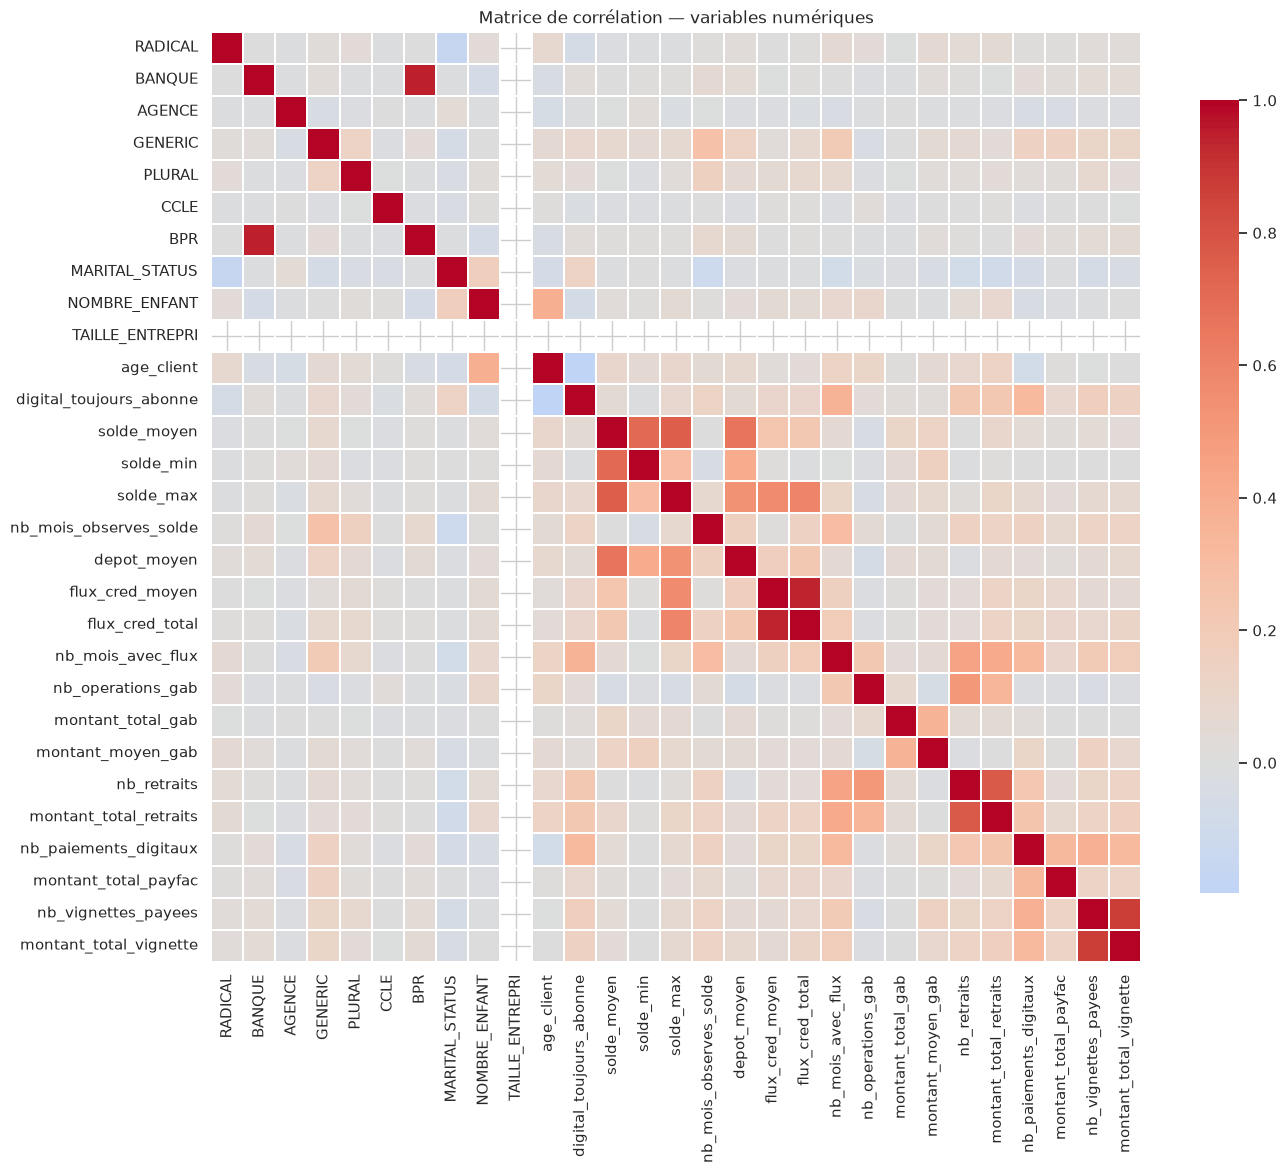

In [62]:
corr = df[real_num_cols].corr()

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr, cmap="coolwarm", center=0, ax=ax, square=True,
            cbar_kws={"shrink": 0.8}, linewidths=0.3)
ax.set_title("Matrice de corrélation — variables numériques")
plt.tight_layout()
plt.show()


In [63]:
# Paires de variables les plus corrélées (hors diagonale), en valeur absolue
corr_pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    .stack()
    .rename("correlation")
    .reset_index()
)
corr_pairs.columns = ["variable_1", "variable_2", "correlation"]
corr_pairs["abs_corr"] = corr_pairs["correlation"].abs()
corr_pairs.sort_values("abs_corr", ascending=False).head(20).drop(columns="abs_corr")


,variable_1,variable_2,correlation
35,BANQUE,BPR,0.948718
511,flux_cred_moyen,flux_cred_total,0.935436
811,nb_vignettes_payees,montant_total_vignette,0.868908
691,nb_retraits,montant_total_retraits,0.767127
362,solde_moyen,solde_max,0.756165
361,solde_moyen,solde_min,0.717841
364,solde_moyen,depot_moyen,0.663548
424,solde_max,flux_cred_total,0.594150
423,solde_max,flux_cred_moyen,0.562751
422,solde_max,depot_moyen,0.536860


In [64]:
# Zoom : paires fortement corrélées (|r| > 0.7)
strong = corr_pairs[corr_pairs["abs_corr"] > 0.7].sort_values("abs_corr", ascending=False)
print(f"{len(strong)} paires avec |corrélation| > 0.7")
strong.drop(columns="abs_corr")


6 paires avec |corrélation| > 0.7


,variable_1,variable_2,correlation
35,BANQUE,BPR,0.948718
511,flux_cred_moyen,flux_cred_total,0.935436
811,nb_vignettes_payees,montant_total_vignette,0.868908
691,nb_retraits,montant_total_retraits,0.767127
362,solde_moyen,solde_max,0.756165
361,solde_moyen,solde_min,0.717841


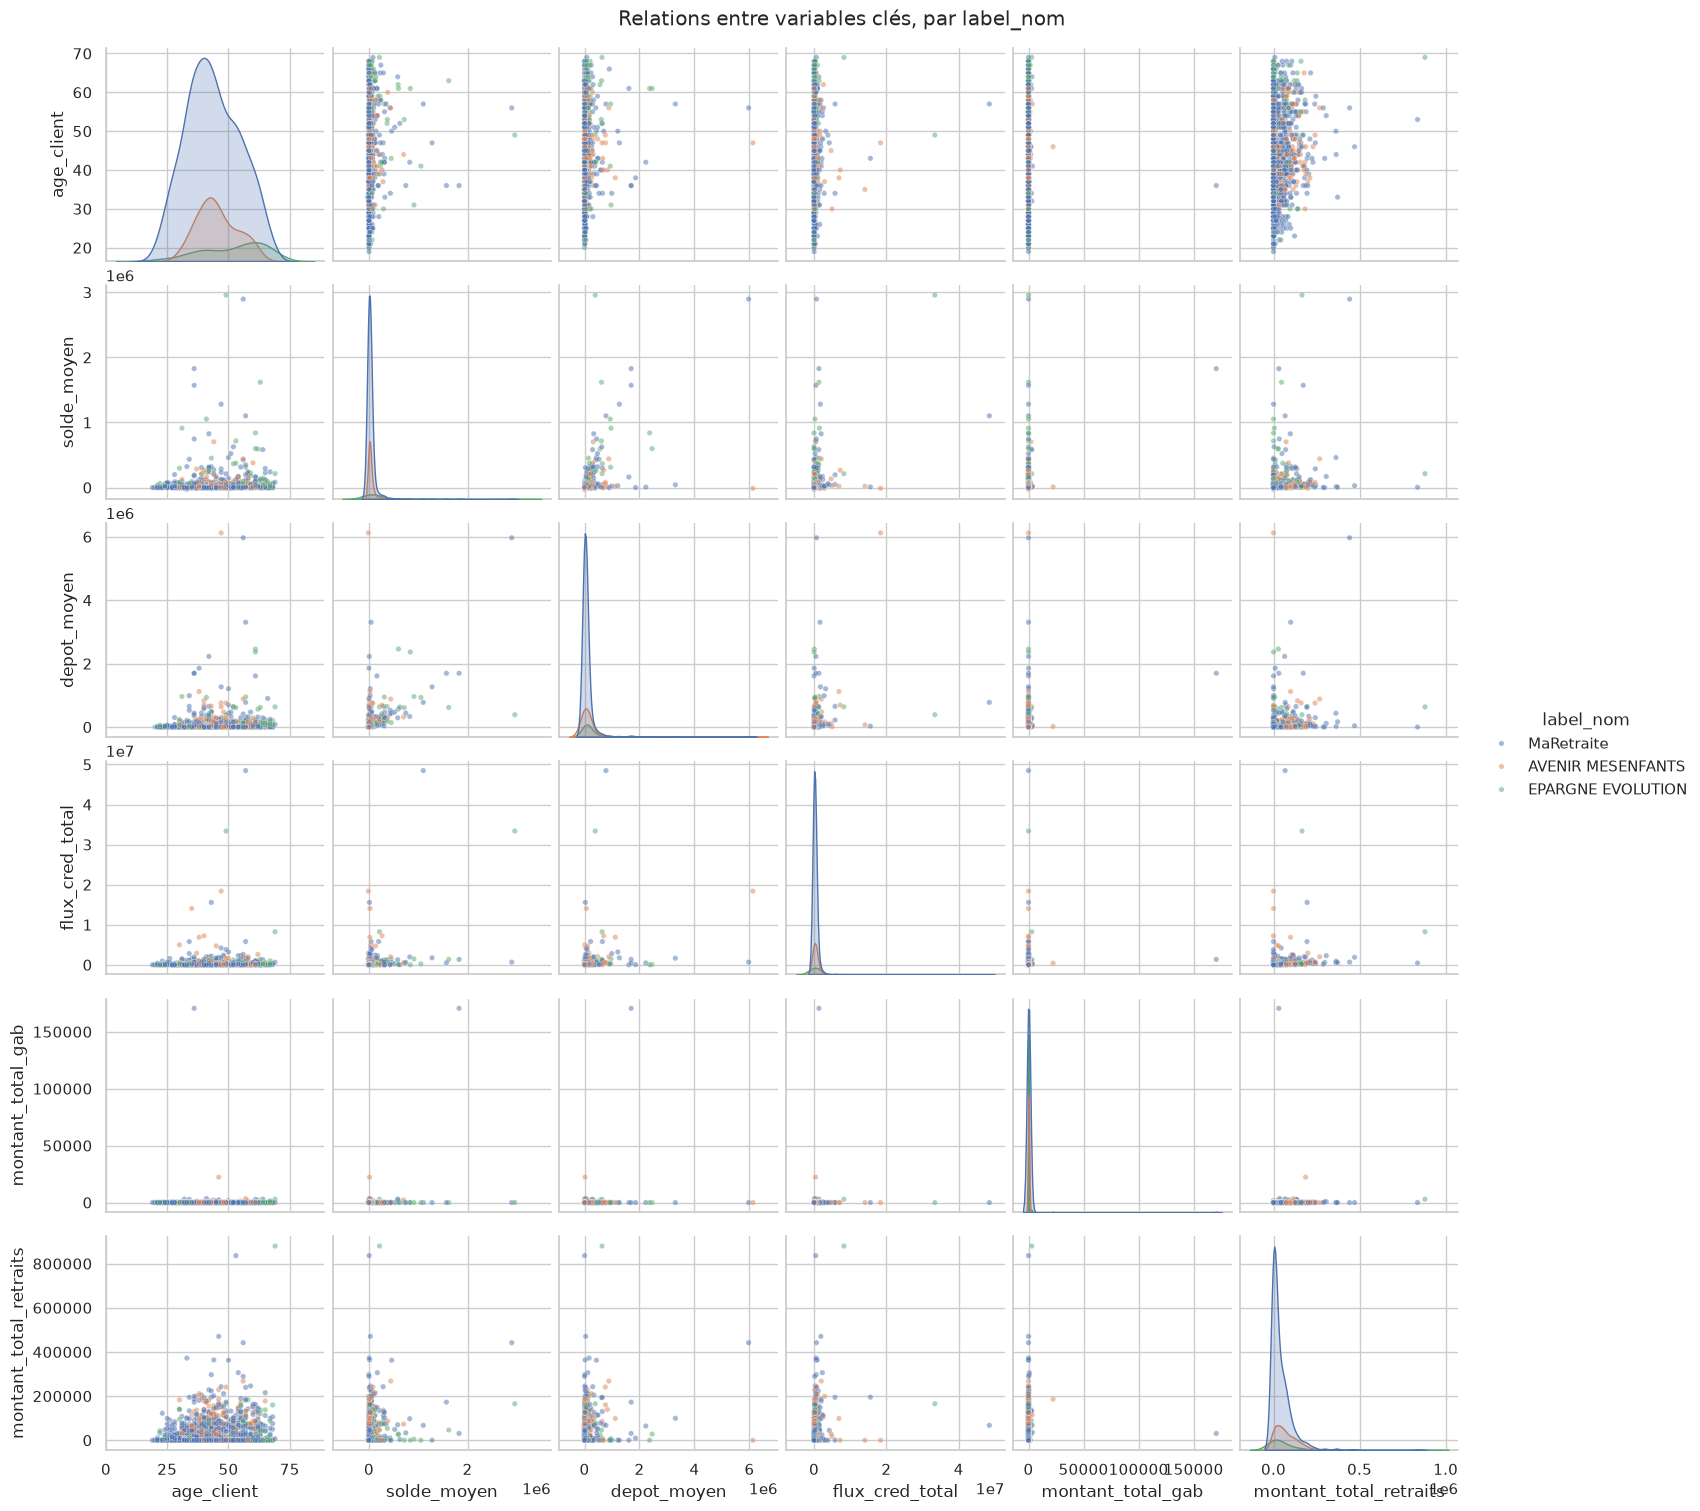

In [65]:
# Pairplot sur un sous-ensemble de variables clés (à adapter selon les besoins)
key_vars = ["age_client", "solde_moyen", "depot_moyen", "flux_cred_total",
            "montant_total_gab", "montant_total_retraits"]
key_vars = [c for c in key_vars if c in df.columns]

sns.pairplot(df[key_vars + ["label_nom"]].sample(min(1000, len(df)), random_state=42),
             hue="label_nom", diag_kind="kde", plot_kws={"alpha": 0.5, "s": 15})
plt.suptitle("Relations entre variables clés, par label_nom", y=1.01)
plt.show()


## 8. Variables numériques vs. cible (`label_nom`)

Boxplots comparant la distribution de chaque variable numérique clé selon la classe cible.

/tmp/ipykernel_383493/1758376510.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="label_nom", y=col, ax=ax, palette="deep", showfliers=False)
/tmp/ipykernel_383493/1758376510.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="label_nom", y=col, ax=ax, palette="deep", showfliers=False)
/tmp/ipykernel_383493/1758376510.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="label_nom", y=col, ax=ax, palette="deep", showfliers=False)
/tmp/ipykernel_383493/1758376510.py:14: FutureWarning: 

Passing `palette

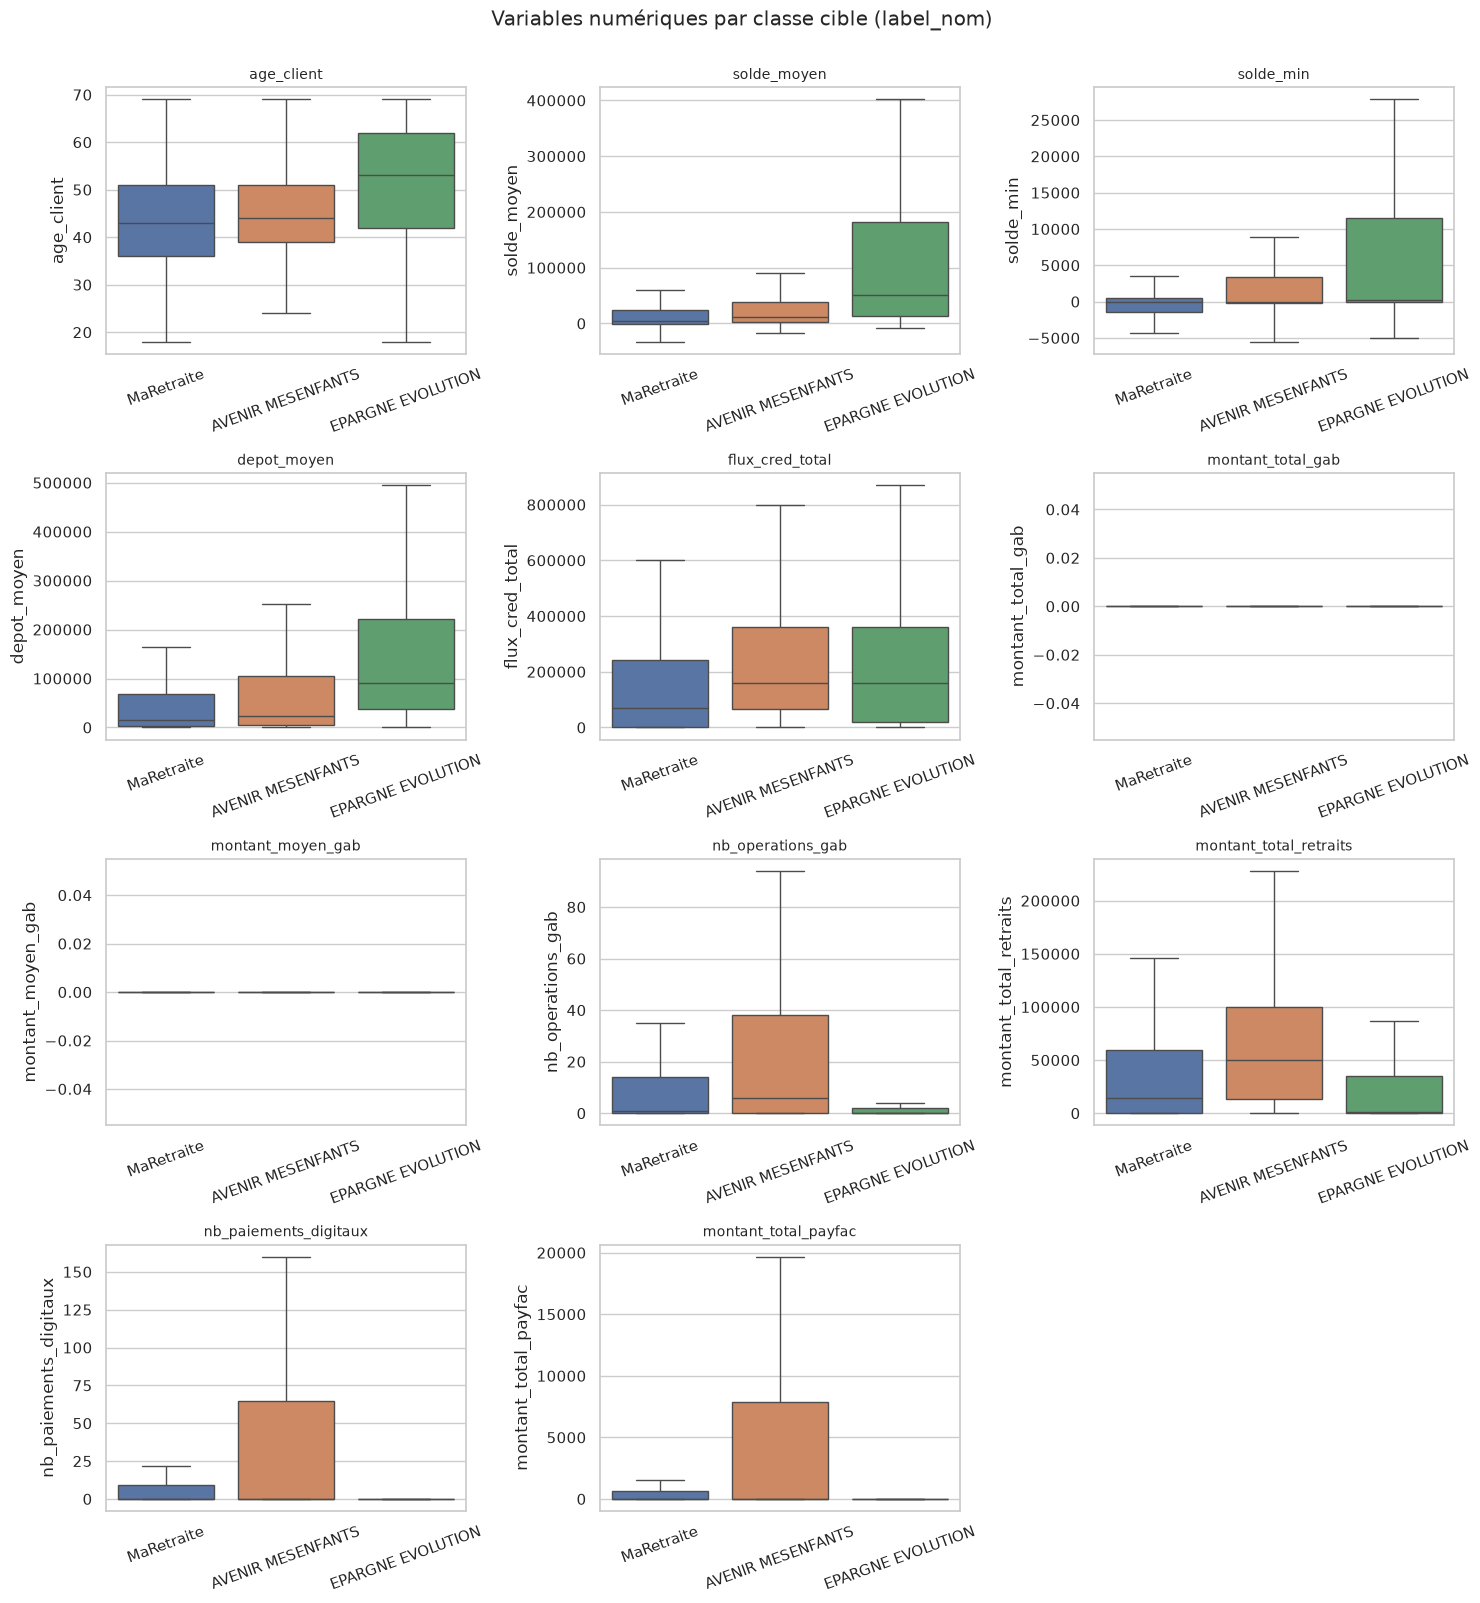

In [66]:
plot_vars = ["age_client", "solde_moyen", "solde_min", "depot_moyen", "flux_cred_total",
             "montant_total_gab", "montant_moyen_gab", "nb_operations_gab",
             "montant_total_retraits", "nb_paiements_digitaux", "montant_total_payfac",
             "anciennete_digitale_jours_imp", "recence_gab_jours_imp", "solde_volatilite_relative"]
plot_vars = [c for c in plot_vars if c in real_num_cols]

ncols = 3
nrows = int(np.ceil(len(plot_vars) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*5, nrows*4))
axes = axes.flatten()

for i, col in enumerate(plot_vars):
    ax = axes[i]
    sns.boxplot(data=df, x="label_nom", y=col, ax=ax, palette="deep", showfliers=False)
    ax.set_title(col, fontsize=10)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=20)

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Variables numériques par classe cible (label_nom)", y=1.001)
plt.tight_layout()
plt.show()


In [67]:
# Moyennes par classe cible pour toutes les variables numériques continues
df.groupby("label_nom")[real_num_cols].mean().T


label_nom,AVENIR MESENFANTS,EPARGNE EVOLUTION,MaRetraite
RADICAL,5.262379e+06,4.674294e+06,4.949846e+06
BANQUE,5.535484e+01,5.472378e+01,5.343783e+01
AGENCE,4.594135e+01,4.553846e+01,4.590164e+01
GENERIC,2.111351e+04,2.111137e+04,2.111333e+04
PLURAL,6.598240e-01,7.447552e-01,6.601974e-01
CCLE,4.262463e+00,4.423077e+00,4.443092e+00
BPR,5.381672e+01,5.208392e+01,5.170013e+01
MARITAL_STATUS,2.835777e+00,3.206294e+00,2.812171e+00
NOMBRE_ENFANT,9.441088e-01,1.081081e+00,7.359093e-01
TAILLE_ENTREPRI,NaN,NaN,9.900000e+01


## 9. Variables catégorielles vs. cible

Répartition de `label_nom` au sein de chaque modalité (pour les catégorielles à cardinalité raisonnable).

In [68]:
low_card_cats = [c for c in cat_cols if df[c].nunique() <= 15]
print(low_card_cats)


['GENDER', 'CUSTOMER_RATING', 'pack_etat']


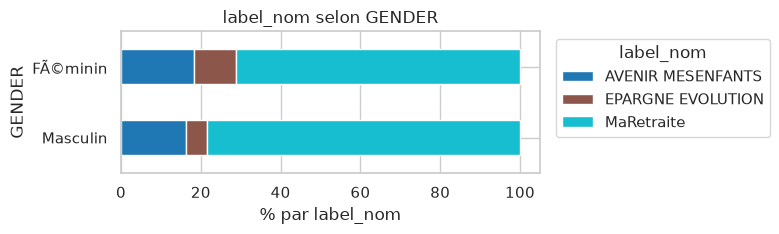

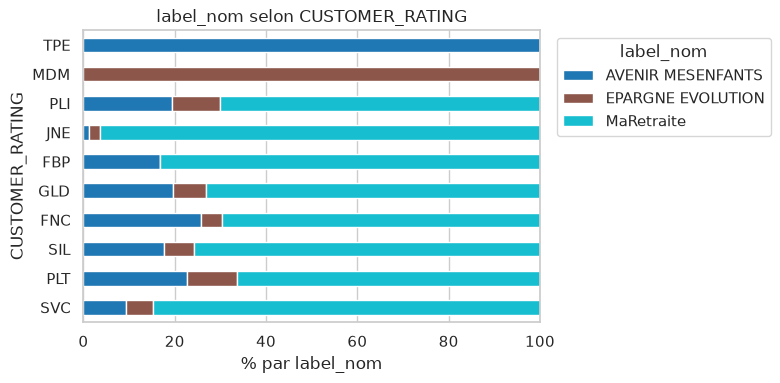

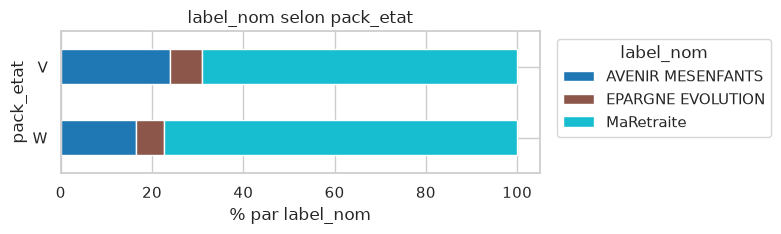

In [69]:
for col in low_card_cats:
    ct = pd.crosstab(df[col], df["label_nom"], normalize="index") * 100
    ct = ct.loc[df[col].value_counts().index]  # trier par fréquence

    fig, ax = plt.subplots(figsize=(8, max(2.5, 0.4*len(ct))))
    ct.plot(kind="barh", stacked=True, ax=ax, colormap="tab10")
    ax.set_xlabel("% par label_nom")
    ax.set_title(f"label_nom selon {col}")
    ax.legend(title="label_nom", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()


In [70]:
# Flags binaires vs cible : taux d'activation par classe
flag_by_target = df.groupby("label_nom")[flag_cols].mean().T * 100
flag_by_target


label_nom,AVENIR MESENFANTS,EPARGNE EVOLUTION,MaRetraite


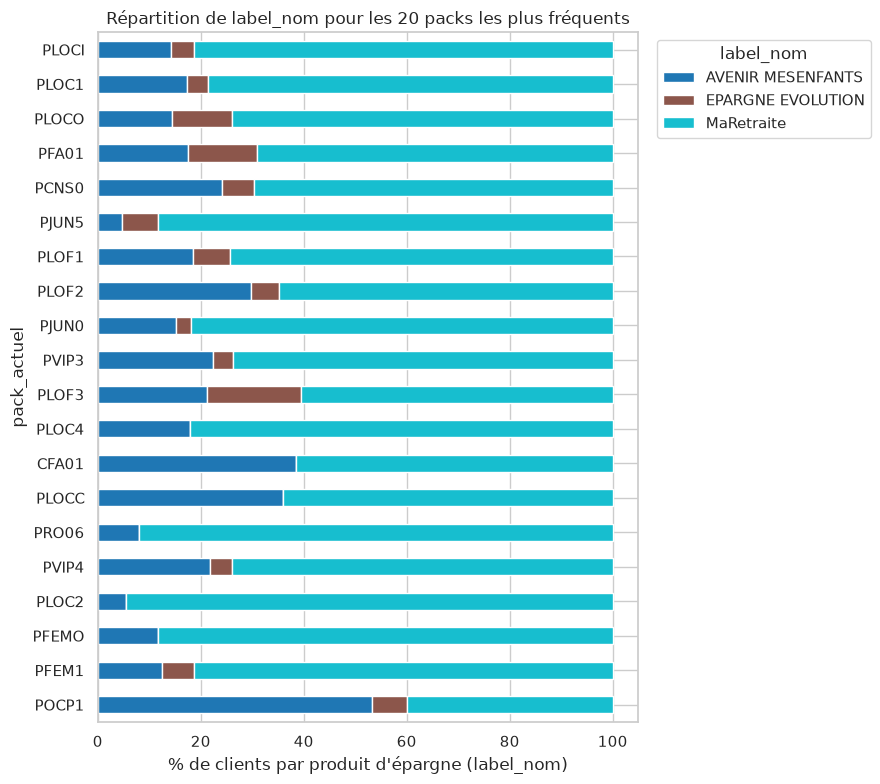

label_nom,AVENIR MESENFANTS,EPARGNE EVOLUTION,MaRetraite
pack_actuel,,,
PLOCI,14.3,4.3,81.4
PLOC1,17.4,4.0,78.7
PLOCO,14.4,11.6,74.0
PFA01,17.5,13.5,69.0
PCNS0,24.1,6.2,69.7
PJUN5,4.7,7.1,88.2
PLOF1,18.6,7.1,74.4
PLOF2,29.7,5.4,64.9
PJUN0,15.2,2.9,81.9


In [71]:
df_pd = pd.read_csv("final.csv")

TOP_N_PACKS = 20
top_packs = df_pd["pack_actuel"].value_counts().head(TOP_N_PACKS).index

ct_pack = pd.crosstab(df_pd.loc[df_pd["pack_actuel"].isin(top_packs), "pack_actuel"],
                       df_pd["label_nom"], normalize="index") * 100
ct_pack = ct_pack.loc[top_packs]

fig, ax = plt.subplots(figsize=(9, max(4, 0.4 * len(ct_pack))))
ct_pack.plot(kind="barh", stacked=True, ax=ax, colormap="tab10")
ax.set_xlabel("% de clients par produit d'épargne (label_nom)")
ax.set_ylabel("pack_actuel")
ax.set_title(f"Répartition de label_nom pour les {TOP_N_PACKS} packs les plus fréquents")
ax.legend(title="label_nom", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

ct_pack.round(1)

In [72]:
df.filter(df["TAILLE_ENTREPRI"] == "99").count()

Series([], dtype: int64)

In [73]:
import matplotlib.pyplot as plt

# Comptage de chaque catégorie
counts = (
    df.groupBy("pack_etat")
      .count()
      .toPandas()
)

# Tracer le diagramme circulaire
plt.figure(figsize=(6, 6))
plt.pie(
    counts["count"],
    labels=counts["pack_etat"],
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Répartition des états des packs")
plt.axis("equal")  # cercle parfait
plt.show()

AttributeError: 'DataFrame' object has no attribute 'groupBy'

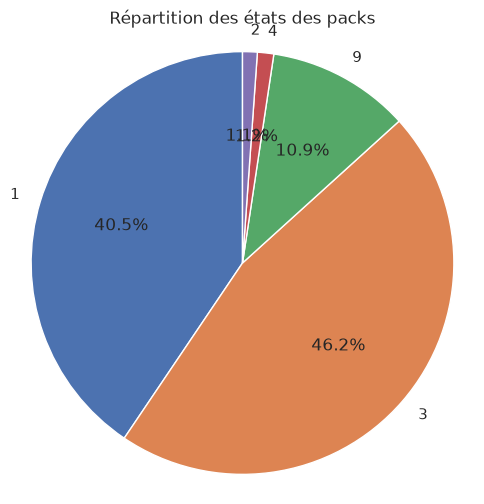

In [ ]:
import matplotlib.pyplot as plt

# Comptage de chaque catégorie
counts = (
    df.groupBy("MARITAL_STATUS")
      .count()
      .toPandas()
)

# Tracer le diagramme circulaire
plt.figure(figsize=(6, 6))
plt.pie(
    counts["count"],
    labels=counts["MARITAL_STATUS"],
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Répartition des états des packs")
plt.axis("equal")  # cercle parfait
plt.show()

## 10. Synthèse

À compléter après lecture des graphiques ci-dessus, par exemple :
- Colonnes avec le plus de valeurs manquantes / cardinalité extrême
- Variables les plus discriminantes vis-à-vis de `label_nom`
- Paires de variables fortement corrélées à surveiller (colinéarité) pour la modélisation MLlib
- Déséquilibre de classes à traiter (pondération, sur/sous-échantillonnage, etc.)
